# 컴퓨터비전 과제 #6

---

## 1. OpenCV 함수를 이용하여 스테레오 정합 결과를 얻는 실험을 수행

- im2와 im6 영상을 이용하여 실험을 수행. 

- 이 영상들은 color 이므로 실험 샘플 코드를 적절히 수정. 

- cv.StereoBM.create 함수는 gray 영상에 대해서만 수행되므로 읽은 실험 영상을 gray로 바꾸어야 함. 

- 실험에서는 numDisparities=64로 지정.

- blocksize를 5, 7, 11, 15로 바꾸어서 결과를 얻는다. block 크기가 결과에 어떤 영향을 주는지 설명.

In [ ]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

im2_path = "im2.png"
im6_path = "im6.png"

im2_color = cv.imread(im2_path)
im6_color = cv.imread(im6_path)

im2 = cv.cvtColor(im2_color, cv.COLOR_BGR2GRAY)
im6 = cv.cvtColor(im6_color, cv.COLOR_BGR2GRAY)

# 두 이미지에서 같은 물체의 위치 차이를 찾을 때 최대로 볼 범위
numDisparities = 64 
# 매칭할 때 비교할 영역의 크기 (더 큰 값 = 더 부드러운 결과, 하지만 세부 사항 손실)
blockSizes = [5, 7, 11, 15]

results = {}

for blockSize in blockSizes:
    stereo = cv.StereoBM_create(numDisparities=numDisparities, blockSize=blockSize)
    disparity = stereo.compute(im2, im6)
    
    disp_norm = cv.normalize(disparity, None, alpha=0, beta=255, norm_type=cv.NORM_MINMAX)
    disp_uint8 = np.uint8(disp_norm)
    
    results[blockSize] = disp_uint8


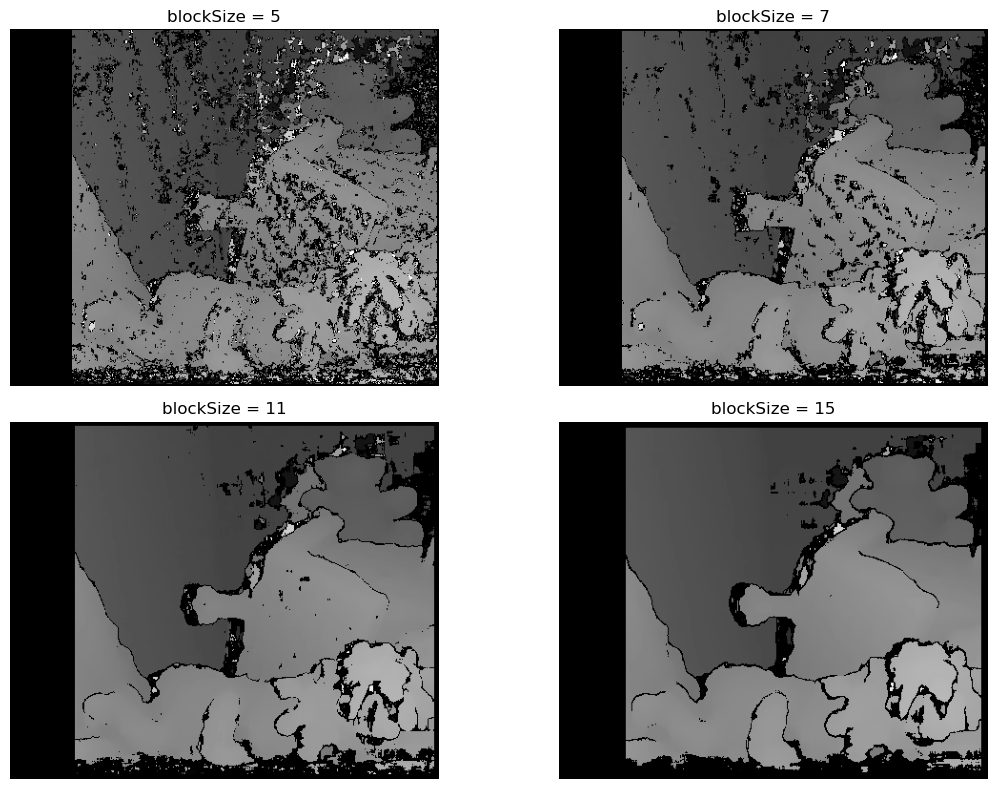

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
axs = axs.ravel()

for idx, blockSize in enumerate(sorted(results.keys())):
    axs[idx].imshow(results[blockSize], cmap='gray')
    axs[idx].set_title(f'blockSize = {blockSize}')
    axs[idx].axis('off')

plt.tight_layout()
plt.show()

## blockSize 변화에 따른 시각적 차이 및 해석

| blockSize | 특징 및 분석 |
| --- | --- |
| **5** | 텍스처가 복잡한 영역에서는 비교적 디테일이 살아 있으나, 노이즈가 많고 전체적으로 점잡음(speckle noise)이 심함 |
| **7** | 디테일은 유지되면서도 조금 더 부드러워짐. 여전히 노이즈 존재 |
| **11** | 전체적으로 매끄러운 disparity map 형성. 윤곽이 뚜렷해지고 노이즈가 크게 줄어듦 |
| **15** | 매우 부드러운 결과. 그러나 세부 경계(예: 식물 등)에서는 과도한 평탄화로 인해 경계가 흐려짐 |

---

## 2. LiDAR에 관한 동영상을 시청, 다른 자료들도 검색하여 기능을 탐색하여 a, b에 답하기

### a) **LiDAR에서 3D 정보를 수집하는 원리와 측정된 거리의 정확도**

LiDAR(Light Detection and Ranging)는 고출력 레이저 펄스를 목표물에 발사하고, 해당 레이저가 물체에 반사되어 다시 수신기로 되돌아오는 **왕복 시간(Time of Flight, ToF)**을 측정하여 거리 정보를 계산하는 원리임.

빛의 속도(c)와 왕복 시간(t)을 이용해 물체까지의 거리(d)를 아래와 같이 산출함:

$$ d=(c×t)/2 $$

이러한 원리를 기반으로 LiDAR 센서는 초당 수십만에서 수백만 개에 달하는 펄스를 연속적으로 방출하며, 각기 다른 방향에서 반사되어 돌아오는 시간을 측정함. 

이처럼 수집된 거리 데이터를 기반으로 3차원 좌표계 상의 점 집합(Point Cloud)을 구성하고, 이를 통해 주변 환경의 입체적 구조를 재현함.

최근 상용화된 고성능 LiDAR 장치는 초당 50만 개 이상의 펄스를 방출하며, 고해상도의 3D 공간 정보를 생성할 수 있음. 

거리 측정 정확도는 LiDAR의 유형 및 사용 환경에 따라 다르게 나타남. 

일반적으로 산업용 고정밀 LiDAR는 **1mm 이하**의 정밀도를 가지며, 차량용 중·단거리 LiDAR는 **±2~5cm 수준**의 정확도를 가짐. 

거리 오차는 대기 상태, 조명 환경, 물체의 반사율 등에 따라 영향을 받음.


### (b) **LiDAR 장치가 회전하는 이유와 초당 처리 영상 수**

LiDAR 장치가 회전하는 이유는 **넓은 시야각(특히 360도 전방위 시야)**를 확보하기 위함임. 

회전식 LiDAR는 모터를 활용하여 센서 본체 또는 내부 미러를 회전시키는 구조를 가짐. 

이를 통해 레이저 빔을 상하좌우 다양한 각도로 분산 방출하여, 특정 방향이 아닌 전체 공간에 대한 거리 정보를 빠르게 획득함. 

이와 같은 방식은 고정된 시야만을 제공하는 일반적인 비회전형 센서와는 구별됨.

회전식 방식 이외에도 **고정형(Solid-State)** 또는 **MEMS(Micro-Electro-Mechanical Systems)**, **OPA(Optical Phased Array)** 기반 LiDAR도 존재함. 

이들은 회전 없이 전자식 방식으로 방향을 조절하며, 내구성과 소형화 측면에서 장점이 있으나, 일반적으로 회전식 대비 좁은 시야각과 낮은 점밀도를 가짐.

초당 처리 가능한 프레임 수는 장치에 따라 다르나, 일반적으로 **10~20fps(프레임/초)** 수준임. 

고성능 장비는 초당 수십만~수백만 개의 포인트를 측정할 수 있으며, 실시간으로 3차원 점군 데이터를 생성함. 

일부 자율주행용 LiDAR는 **초당 64~128개의 수직 스캔 라인**을 방출하여 고해상도 환경 인식을 수행함.


#### Reference:

- https://youtu.be/3EehCU3csJQ?si=iiQ00TDENX91oONp

Lidar Technologies 101

- https://youtu.be/H2-Yp30TGk4?si=gADRjGLPTa4Yg5YY

What is Lidar? How does Lidar work? Know all about LiDAR

- https://kr.appen.com/blog/lidar/

라이다(LiDAR)란? 정의, 구성 요소, 작동 방식

- https://blog.naver.com/jhongban/223174868843

라이다의 원리 및 활용



---

## 3. 수업자료 12장 35쪽 Laser 센서 방식 설명 및 LiDAR와의 비교

### (a) 이 방식에서는 거리를 어떻게 측정하는지 설명

구조광(Structured Light) 방식의 3D Laser Scanner는 **레이저와 특수 렌즈**를 이용하여 **평면파(plane wave)**를 물체 표면에 투사함. 

이때 투사된 평면파는 정해진 광학적 패턴을 형성하며, 그 패턴이 물체의 표면 형상에 따라 왜곡되게 나타남.

카메라는 이 왜곡된 패턴을 촬영하고, 촬영된 영상 내에서의 왜곡된 위치를 해석함으로써, **카메라 투사 방정식(projection equation)**과 **평면파의 광학적 수식**을 결합하여 각 점까지의 거리를 역산할 수 있음.

즉, **정확하게 설계된 광학 모델**과 **카메라의 캘리브레이션 정보**를 활용하여, 영상 내 각 픽셀의 위치와 대응되는 3차원 위치를 계산하는 원리임.

영상 기반 분석에서 광선의 굴절, 레이저의 입사각, 카메라 위치 및 렌즈 파라미터 등이 모두 거리 계산에 반영되며, 이를 통해 고정밀 3D 표면 정보를 획득할 수 있음.

CadabraLabs의 Moedls와 같은 장치는 구조광 원리를 활용하되, **스마트폰 카메라 + 라인 레이저 + 회전 플랫폼**의 간단한 구성으로 이를 실현함.

회전하면서 360도 전 방향에서 **레이저 평면이 물체 표면과 만나는 교차선(라인)**을 추적하고, 이 라인을 **프레임 단위로 축적**하여 3D 모델을 생성함.


### (b) 이 방식을 LiDAR와 비교했을 때의 장단점을 설명하라

### 1. **작동 원리 차이**

| 항목 | 구조광 방식 | LiDAR |
| --- | --- | --- |
| 방식 | 광 패턴 투사 후 카메라로 촬영하여 광학적 왜곡 분석 | 레이저를 발사하고 반사되어 돌아오는 시간(ToF)을 측정 |
| 구성 | 라인 레이저 + 카메라 + 고정 각도 | 레이저 송수신 장치 단독으로 거리 측정 가능 |
| 투사 대상 | 광학 패턴(직선 또는 격자) | 단일 펄스 또는 다중 펄스의 레이저 빔 |


### 2. **장점 비교**

| 항목 | 구조광 방식 | LiDAR |
| --- | --- | --- |
| 고정밀 근거리 측정 | 가능 (미세 표면 스캔에 적합) | 상대적으로 정확도 낮음 (수 cm 이상) |
| 비용 및 접근성 | 저렴하고 간단한 구성 가능 | 고가의 센서와 모터 기반 시스템 필요 |
| 실내 환경 적합성 | 조명이 통제되는 환경에서 우수 | 밝은 조명에서도 견고한 성능 보임 |


### 3. **단점 비교**

| 항목 | 구조광 방식 | LiDAR |
| --- | --- | --- |
| 조명 의존성 | 외부 빛 간섭에 매우 민감 | 적외선 기반으로 외부광 영향 적음 |
| 거리 측정 범위 | 근거리 (보통 수십 cm ~ 1m 이내) | 장거리 가능 (수십 m 이상) |
| 실시간성 | 실시간 처리 어려움 (영상 후처리 필요) | 실시간 거리 계산 가능 |

### 4. **응용 분야 비교**

| 항목 | 구조광 방식 | LiDAR |
| --- | --- | --- |
| 적합 분야 | 정밀 표면 스캔, 소형 객체 모델링, 얼굴 인식 | 자율주행, 공간 지도화, 로봇 항법 |
| 대표 기술 | Apple Face ID, Moedls 앱 | Velodyne, Hesai, Ouster 등 자율주행용 센서 |

구조광 방식은 정밀도는 높지만 **조명 조건과 측정 거리 제한**이 있으며, 영상 기반 후처리를 요구하는 반면,

LiDAR는 **넓은 범위와 빠른 거리 측정에 강점**이 있으나 구조광만큼의 정밀 표면 복원 능력은 부족함.

따라서 **목적과 환경에 따라 기술 선택이 달라지는 보완적 관계**에 있음.